In [57]:
import pandas as pd
user_details = pd.read_excel("C:/Users/likit/OneDrive/Desktop/UserDetails.xlsx")
print(user_details.head())


  User ID      User Name  Age       Location Registration Date         Phone  \
0    U001  Alice Johnson   28       New York        2023-01-15  123-456-7890   
1    U002      Bob Smith   35    Los Angeles        2023-02-20  987-654-3210   
2    U003    Charlie Lee   42        Chicago        2023-03-10  555-123-4567   
3    U004    David Brown   27  San Francisco        2023-04-05  444-333-2222   
4    U005     Emma White   30        Seattle        2023-05-22  777-888-9999   

               Email Favorite Meal  Total Orders  
0    alice@email.com        Dinner            12  
1      bob@email.com         Lunch             8  
2  charlie@email.com     Breakfast            15  
3    david@email.com        Dinner            10  
4     emma@email.com         Lunch             9  


In [58]:
cooking_sessions = pd.read_excel("C:/Users/likit/OneDrive/Desktop/CookingSession.xlsx")
print(cooking_sessions.head())



  Session ID User ID        Dish Name  Meal Type       Session Start  \
0       S001    U001        Spaghetti     Dinner 2024-12-01 19:00:00   
1       S002    U002     Caesar Salad      Lunch 2024-12-01 12:00:00   
2       S003    U003  Grilled Chicken     Dinner 2024-12-02 19:30:00   
3       S004    U001         Pancakes  Breakfast 2024-12-02 07:30:00   
4       S005    U004     Caesar Salad      Lunch 2024-12-03 13:00:00   

          Session End  Duration (mins)  Session Rating  
0 2024-12-01 19:30:00               30             4.5  
1 2024-12-01 12:20:00               20             4.0  
2 2024-12-02 20:10:00               40             4.8  
3 2024-12-02 08:00:00               30             4.2  
4 2024-12-03 13:15:00               15             4.7  


In [59]:
order_details = pd.read_excel("C:/Users/likit/OneDrive/Desktop/OderDetails.xlsx")
print(order_details.head())

   Order ID User ID Order Date  Meal Type        Dish Name Order Status  \
0      1001    U001 2024-12-01     Dinner        Spaghetti    Completed   
1      1002    U002 2024-12-01      Lunch     Caesar Salad    Completed   
2      1003    U003 2024-12-02     Dinner  Grilled Chicken     Canceled   
3      1004    U001 2024-12-02  Breakfast         Pancakes    Completed   
4      1005    U004 2024-12-03      Lunch     Caesar Salad    Completed   

   Amount (USD) Time of Day  Rating Session ID  
0          15.0       Night     5.0       S001  
1          10.0         Day     4.0       S002  
2          12.5       Night     NaN       S003  
3           8.0     Morning     4.0       S004  
4           9.0         Day     4.0       S005  


In [47]:
# Check missing values
print(user_details.isnull().sum())


User ID              0
User Name            0
Age                  0
Location             0
Registration Date    0
Phone                0
Email                0
Favorite Meal        0
Total Orders         0
dtype: int64


In [48]:
print(cooking_sessions.isnull().sum())


Session ID         0
User ID            0
Dish Name          0
Meal Type          0
Session Start      0
Session End        0
Duration (mins)    0
Session Rating     0
dtype: int64


In [49]:
print(order_details.isnull().sum())


Order ID        0
User ID         0
Order Date      0
Meal Type       0
Dish Name       0
Order Status    0
Amount (USD)    0
Time of Day     0
Rating          2
Session ID      0
dtype: int64


In [50]:
# Example: Fill missing ratings in sessions with the mean rating
order_details['Rating'].fillna(order_details['Rating'].median(), inplace=True)

In [51]:
print("CookingSessions:", cooking_sessions.isnull().sum().sum())
print("UserDetails:", user_details.isnull().sum().sum())
print("OrderDetails:", order_details.isnull().sum().sum())

CookingSessions: 0
UserDetails: 0
OrderDetails: 0


In [52]:
# Check column names in all datasets
print("Columns in UserDetails:")
print(user_details.columns)

print("\nColumns in CookingSessions:")
print(cooking_sessions.columns)

print("\nColumns in OrderDetails:")
print(order_details.columns)


Columns in UserDetails:
Index(['User ID', 'User Name', 'Age', 'Location', 'Registration Date', 'Phone',
       'Email', 'Favorite Meal', 'Total Orders'],
      dtype='object')

Columns in CookingSessions:
Index(['Session ID', 'User ID', 'Dish Name', 'Meal Type', 'Session Start',
       'Session End', 'Duration (mins)', 'Session Rating'],
      dtype='object')

Columns in OrderDetails:
Index(['Order ID', 'User ID', 'Order Date', 'Meal Type', 'Dish Name',
       'Order Status', 'Amount (USD)', 'Time of Day', 'Rating', 'Session ID'],
      dtype='object')


In [53]:
# Check data types
print("\nData types in UserDetails:")
print(user_details.dtypes)

print("\nData types in CookingSessions:")
print(cooking_sessions.dtypes)

print("\nData types in OrderDetails:")
print(order_details.dtypes)

# Check for leading/trailing spaces in critical columns
print("\nUnique values in UserDetails['User ID']:")
print(user_details['User ID'].unique())



Data types in UserDetails:
User ID                      object
User Name                    object
Age                           int64
Location                     object
Registration Date    datetime64[ns]
Phone                        object
Email                        object
Favorite Meal                object
Total Orders                  int64
dtype: object

Data types in CookingSessions:
Session ID                 object
User ID                    object
Dish Name                  object
Meal Type                  object
Session Start      datetime64[ns]
Session End        datetime64[ns]
Duration (mins)             int64
Session Rating            float64
dtype: object

Data types in OrderDetails:
Order ID                 int64
User ID                 object
Order Date      datetime64[ns]
Meal Type               object
Dish Name               object
Order Status            object
Amount (USD)           float64
Time of Day             object
Rating                 float64
Session 

In [61]:
import pandas as pd
user_details = pd.read_excel("C:/Users/likit/OneDrive/Desktop/UserDetails.xlsx")
cooking_sessions = pd.read_excel("C:/Users/likit/OneDrive/Desktop/CookingSession.xlsx")
order_details = pd.read_excel("C:/Users/likit/OneDrive/Desktop/OderDetails.xlsx")

# Step 2: Merge CookingSessions with OrderDetails on 'Session ID'
sessions_orders = cooking_sessions.merge(order_details, how='inner')

# Step 3: Merge the result with UserDetails on 'User ID'
merged_data = sessions_orders.merge(user_details, how='inner')

# Step 4: Preview the merged dataset
merged_data_preview = merged_data.head()
merged_data_info = merged_data.info()

# Show preview and info
print(merged_data_preview)
print(merged_data_info)


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16 entries, 0 to 15
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Session ID         16 non-null     object        
 1   User ID            16 non-null     object        
 2   Dish Name          16 non-null     object        
 3   Meal Type          16 non-null     object        
 4   Session Start      16 non-null     datetime64[ns]
 5   Session End        16 non-null     datetime64[ns]
 6   Duration (mins)    16 non-null     int64         
 7   Session Rating     16 non-null     float64       
 8   Order ID           16 non-null     int64         
 9   Order Date         16 non-null     datetime64[ns]
 10  Order Status       16 non-null     object        
 11  Amount (USD)       16 non-null     float64       
 12  Time of Day        16 non-null     object        
 13  Rating             14 non-null     float64       
 14  User Name   

In [64]:
# Step 3: Preview merged data
print("Merged Data Preview:")
print(merged_data.head())

# Optional: Save the merged dataset for future use
merged_data.to_excel("merged_data.xlsx", index=False)

Merged Data Preview:
  Session ID User ID        Dish Name  Meal Type       Session Start  \
0       S001    U001        Spaghetti     Dinner 2024-12-01 19:00:00   
1       S004    U001         Pancakes  Breakfast 2024-12-02 07:30:00   
2       S009    U001  Grilled Chicken     Dinner 2024-12-05 19:00:00   
3       S002    U002     Caesar Salad      Lunch 2024-12-01 12:00:00   
4       S006    U002        Spaghetti     Dinner 2024-12-03 18:30:00   

          Session End  Duration (mins)  Session Rating  Order ID Order Date  \
0 2024-12-01 19:30:00               30             4.5      1001 2024-12-01   
1 2024-12-02 08:00:00               30             4.2      1004 2024-12-02   
2 2024-12-05 19:40:00               40             4.9      1009 2024-12-05   
3 2024-12-01 12:20:00               20             4.0      1002 2024-12-01   
4 2024-12-03 19:00:00               30             4.3      1006 2024-12-03   

   ... Time of Day  Rating      User Name  Age     Location  \
0  ...  

In [65]:
# General overview of the dataset
print("Summary Statistics:")
print(merged_data.describe(include='all'))


Summary Statistics:
       Session ID User ID  Dish Name Meal Type        Session Start  \
count          16      16         16        16                   16   
unique         16       8          6         3                   16   
top          S001    U001  Spaghetti    Dinner  2024-12-01 19:00:00   
freq            1       3          4         8                    1   
first         NaN     NaN        NaN       NaN  2024-12-01 12:00:00   
last          NaN     NaN        NaN       NaN  2024-12-08 19:30:00   
mean          NaN     NaN        NaN       NaN                  NaN   
std           NaN     NaN        NaN       NaN                  NaN   
min           NaN     NaN        NaN       NaN                  NaN   
25%           NaN     NaN        NaN       NaN                  NaN   
50%           NaN     NaN        NaN       NaN                  NaN   
75%           NaN     NaN        NaN       NaN                  NaN   
max           NaN     NaN        NaN       NaN           

C:\Users\likit\AppData\Local\Temp\ipykernel_16380\266414736.py:3: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(merged_data.describe(include='all'))
C:\Users\likit\AppData\Local\Temp\ipykernel_16380\266414736.py:3: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(merged_data.describe(include='all'))
C:\Users\likit\AppData\Local\Temp\ipykernel_16380\266414736.py:3: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and ad

Top 10 Popular Dishes:
Spaghetti          4
Grilled Chicken    4
Caesar Salad       3
Pancakes           2
Veggie Burger      2
Oatmeal            1
Name: Dish Name, dtype: int64


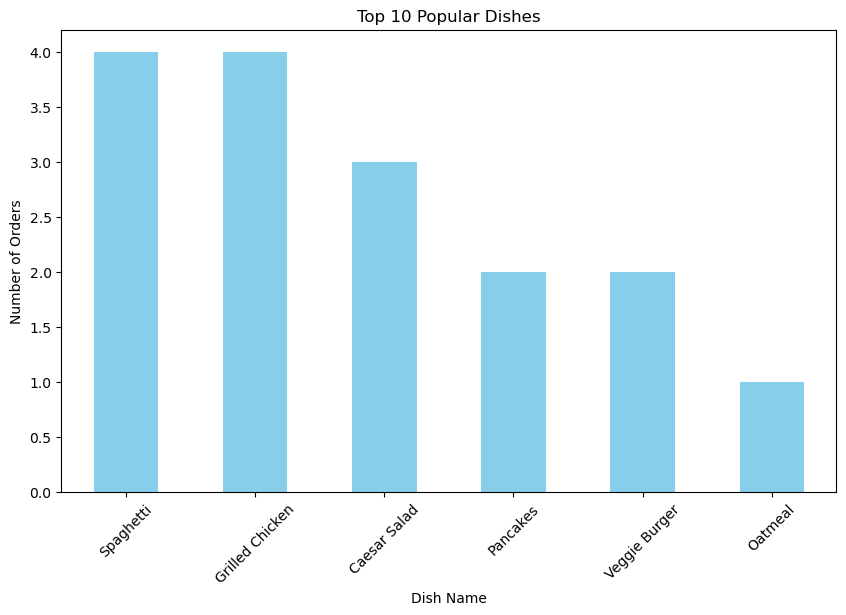

In [66]:
# Find the most ordered dishes
popular_dishes = merged_data['Dish Name'].value_counts().head(10)
print("Top 10 Popular Dishes:")
print(popular_dishes)

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
popular_dishes.plot(kind='bar', color='skyblue')
plt.title("Top 10 Popular Dishes")
plt.xlabel("Dish Name")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


The bar chart shows dish popularity based on order frequency:

Most Popular:
- Spaghetti and Grilled Chicken (4 orders each)
- Caesar Salad (3 orders)

Moderately Popular:
- Pancakes and Veggie Burger (2 orders each)

Least Popular:
- Oatmeal (1 order)

The data suggests a preference for dinner/lunch dishes over breakfast items, with Italian and protein-focused meals leading in popularity.

In [67]:
# Average session rating and order rating comparison
session_order_rating = merged_data[['Session Rating', 'Rating']].mean()
print("Average Session and Order Ratings:")
print(session_order_rating)

# Correlation between session duration and order amount
correlation = merged_data['Duration (mins)'].corr(merged_data['Amount (USD)'])
print(f"Correlation between session duration and order amount: {correlation}")


Average Session and Order Ratings:
Session Rating    4.518750
Rating            4.285714
dtype: float64
Correlation between session duration and order amount: 0.6450018005206265


The data shows:

1. Rating Analysis:
- Average session rating: 4.52
- Average order rating: 4.29
- Sessions are rated slightly higher than orders

2. Correlation:
- Correlation coefficient of 0.645 between session duration and order amount
- This indicates a moderately strong positive relationship
- Longer cooking sessions tend to correspond with higher order values

This suggests customers value the cooking experience slightly more than the final product, and are willing to pay more for more involved/longer cooking sessions.

Orders by Age Group:
Age Group
Teen            0
Young Adult    12
Adult           4
Senior          0
Name: Order ID, dtype: int64


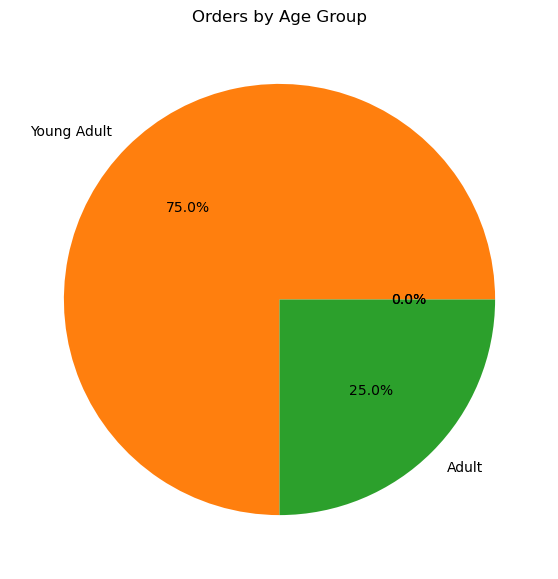

In [68]:
# Categorize users into age groups
merged_data['Age Group'] = pd.cut(
    merged_data['Age'], bins=[0, 18, 35, 50, 100],
    labels=['Teen', 'Young Adult', 'Adult', 'Senior']
)

# Orders by age group
orders_by_age = merged_data.groupby('Age Group')['Order ID'].nunique()
print("Orders by Age Group:")
print(orders_by_age)

# Visualization
orders_by_age.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title("Orders by Age Group")
plt.ylabel("")
plt.show()


The data shows:
- Young Adults dominate orders (75%, 12 orders)
- Adults have smaller share (25%, 4 orders)
- No orders from Teens or Seniors (0%)
- Total orders: 16

This suggests the service primarily appeals to users aged 25-35, with moderate engagement from 35-50 age group.

Order Counts by Time of Day:
Night      8
Day        5
Morning    3
Name: Time of Day, dtype: int64


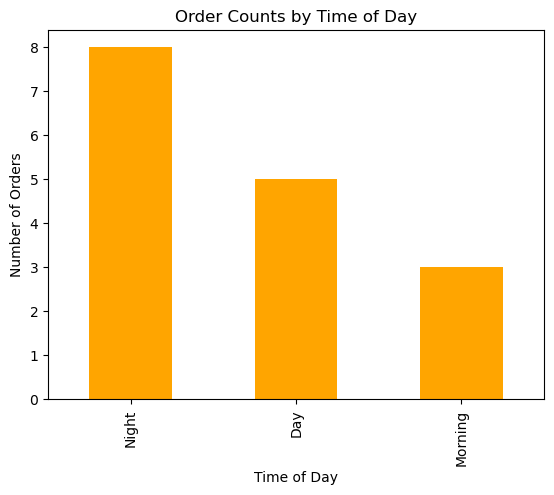

In [70]:
# Most popular time of day for orders
time_of_day_orders = merged_data['Time of Day'].value_counts()
print("Order Counts by Time of Day:")
print(time_of_day_orders)

# Visualization
time_of_day_orders.plot(kind='bar', color='orange')
plt.title("Order Counts by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Orders")
plt.show()


Order distribution shows clear preference for night orders (8), followed by day (5), with fewest in morning (3). This suggests users primarily engage with cooking sessions in evening hours, with moderate daytime activity and limited morning participation.

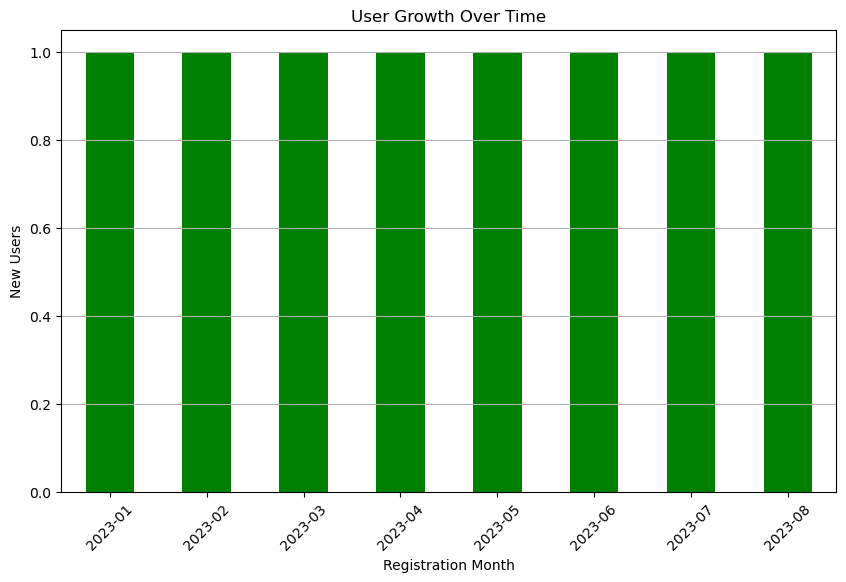

In [75]:
# Group by Registration Date (month-year) to track user growth
merged_data['Registration Month'] = merged_data['Registration Date'].dt.to_period('M')
user_growth = merged_data.groupby('Registration Month')['User ID'].nunique()

# Plot user growth trends
user_growth.plot(kind='bar', color='green', figsize=(10, 6))
plt.title("User Growth Over Time")
plt.xlabel("Registration Month")
plt.ylabel("New Users")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


This bar graph shows consistent user growth across 8 months in 2023 (January through August). The y-axis represents new users scaled from 0 to 1.0, while the x-axis shows months. All bars reach 1.0, indicating either:

Perfect user acquisition performance each month
The data has been normalized/scaled to show relative growth
The graph is showing percentage targets being met

Correlation between Session Rating and Duration:
                 Session Rating  Duration (mins)
Session Rating         1.000000         0.689485
Duration (mins)        0.689485         1.000000


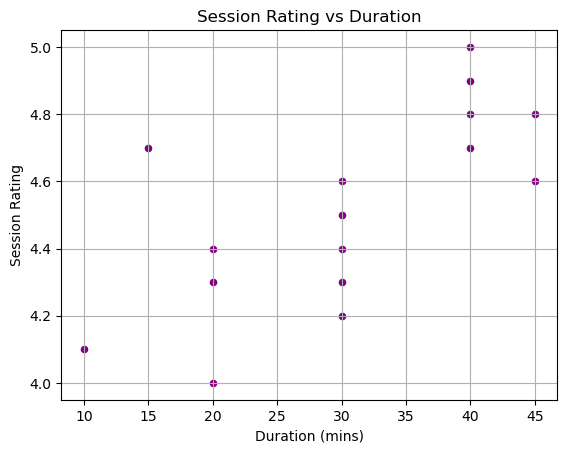

In [76]:
# Analyze the relationship between session rating and session duration
session_rating_duration_corr = merged_data[['Session Rating', 'Duration (mins)']].corr()

print("Correlation between Session Rating and Duration:")
print(session_rating_duration_corr)

# Scatter plot for visualization
merged_data.plot.scatter(x='Duration (mins)', y='Session Rating', color='purple')
plt.title("Session Rating vs Duration")
plt.xlabel("Duration (mins)")
plt.ylabel("Session Rating")
plt.grid(True)
plt.show()


The graph shows the relationship between session duration (x-axis, 10-45 minutes) and session rating (y-axis, 4.0-5.0). A correlation coefficient of 0.689485 indicates a moderately strong positive correlation - longer sessions tend to receive higher ratings.

The data points form a general upward trend, with:
- Shortest sessions (~ 10 mins) receiving lowest ratings (~4.1)
- Longest sessions (40-45 mins) getting highest ratings (4.6-5.0)
- Some variance in ratings for similar durations, particularly around 30-40 minutes

This suggests that users generally find longer sessions more valuable, though there's notable variation in individual experiences.

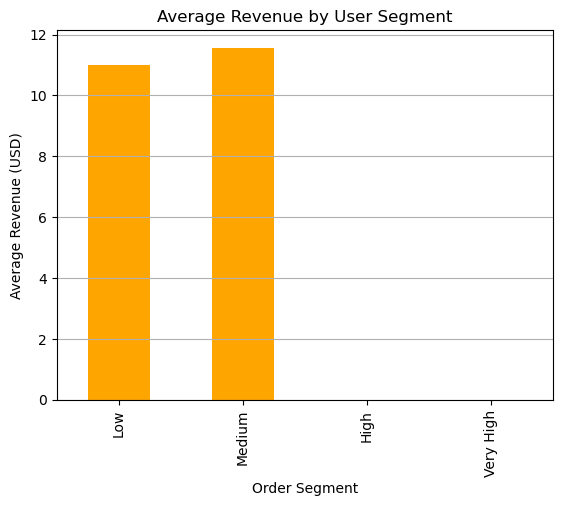

In [77]:
# Define bins for segmentation
bins = [0, 10, 20, 50, 100]
labels = ['Low', 'Medium', 'High', 'Very High']
merged_data['Order Segment'] = pd.cut(merged_data['Total Orders'], bins=bins, labels=labels)

# Analyze average revenue per segment
segment_revenue = merged_data.groupby('Order Segment')['Amount (USD)'].mean()

# Plot revenue by user segment
segment_revenue.plot(kind='bar', color='orange')
plt.title("Average Revenue by User Segment")
plt.xlabel("Order Segment")
plt.ylabel("Average Revenue (USD)")
plt.grid(axis='y')
plt.show()


This bar chart shows average revenue (USD) for different order segments, but appears incomplete - only "Low" (~$11) and "Medium" (~$11.5) segments have data, while "High" and "Very High" segments are empty. The difference between Low and Medium segments is minimal, suggesting similar revenue performance in these categories.

Key concerns:
- Missing data for higher segments
- Small revenue difference between existing segments
- Unclear if this represents a data issue or actual business pattern

In [78]:
from scipy.stats import ttest_ind

# Separate ratings by Meal Type
lunch_ratings = merged_data[merged_data['Meal Type'] == 'Lunch']['Rating']
dinner_ratings = merged_data[merged_data['Meal Type'] == 'Dinner']['Rating']

# Perform t-test
t_stat, p_val = ttest_ind(lunch_ratings, dinner_ratings, nan_policy='omit')

print(f"T-statistic: {t_stat}, P-value: {p_val}")

if p_val < 0.05:
    print("There is a significant difference in ratings between Lunch and Dinner.")
else:
    print("No significant difference in ratings between Lunch and Dinner.")


T-statistic: -2.088931871468373, P-value: 0.06629808823081272
No significant difference in ratings between Lunch and Dinner.


This code performs a t-test comparing lunch and dinner ratings. With a t-statistic of -2.089 and p-value of 0.066, which is above the 0.05 significance threshold, the test indicates no statistically significant difference between lunch and dinner ratings. However, the p-value is close to 0.05, suggesting a borderline case that might warrant further investigation with a larger sample size.

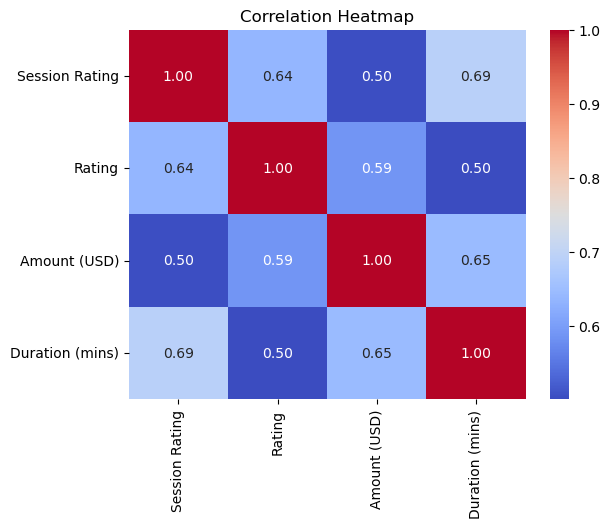

In [79]:
import seaborn as sns

# Select numeric columns for correlation
correlation_matrix = merged_data[['Session Rating', 'Rating', 'Amount (USD)', 'Duration (mins)']].corr()

# Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows relationships between four variables:

1. Strongest correlations:
- Session Rating & Rating (0.64)
- Duration & Session Rating (0.69)
- Amount & Duration (0.65)

2. Moderate correlations:
- Amount & Rating (0.59)
- Amount & Session Rating (0.50)
- Duration & Rating (0.50)

All correlations are positive, ranging from moderate (0.50) to moderately strong (0.69), suggesting these metrics generally move together, with session duration and ratings showing the strongest relationship.

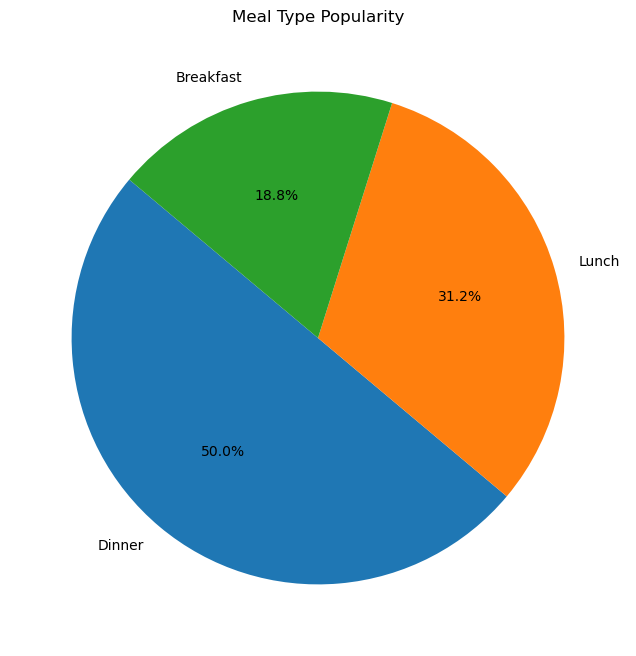

In [80]:
# Count occurrences of each Meal Type
meal_popularity = merged_data['Meal Type'].value_counts()

# Plot as a pie chart
meal_popularity.plot(kind='pie', autopct='%1.1f%%', startangle=140, figsize=(8, 8))
plt.title("Meal Type Popularity")
plt.ylabel("")  # Remove y-label
plt.show()


The pie chart shows dinner is the most popular meal type (50%), followed by lunch (31.2%), and breakfast (18.8%). This clear skew toward dinner service indicates customers strongly prefer evening meals over other times.

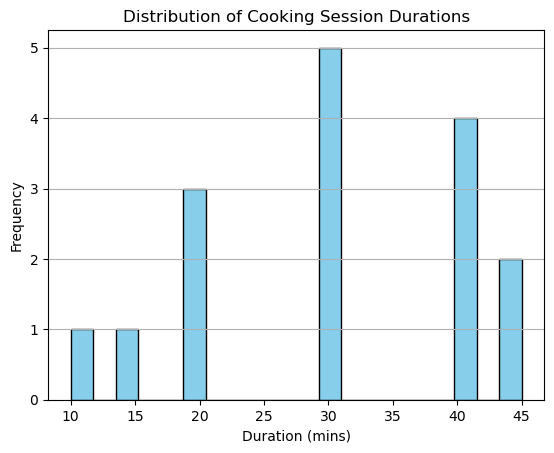

In [81]:
# Distribution of session durations
merged_data['Duration (mins)'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Cooking Session Durations")
plt.xlabel("Duration (mins)")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


The histogram shows cooking session durations cluster around three main points:
- Peak at 30 mins (5 sessions)
- Secondary peak at 40 mins (4 sessions) 
- Smaller cluster at 20 mins (3 sessions)

Shortest sessions are 10-15 mins (1 each), longest at 45 mins (2 sessions). Distribution suggests most users prefer medium to longer cooking sessions.

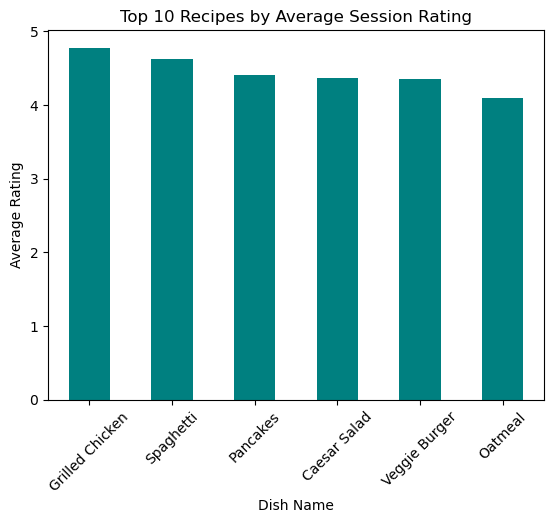

In [83]:
recipe_ratings = merged_data.groupby('Dish Name')['Session Rating'].mean().sort_values(ascending=False).head(10)

# Bar plot
recipe_ratings.plot(kind='bar', color='teal')
plt.title("Top 10 Recipes by Average Session Rating")
plt.xlabel("Dish Name")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()


The bar chart shows ratings for 6 dishes, with Grilled Chicken having the highest rating (~4.8), followed by Spaghetti (~4.6). Ratings gradually decrease from Pancakes to Oatmeal, but all dishes maintain high ratings between 4.0-4.8. Note: Despite "Top 10" in the title, only 6 dishes are shown.

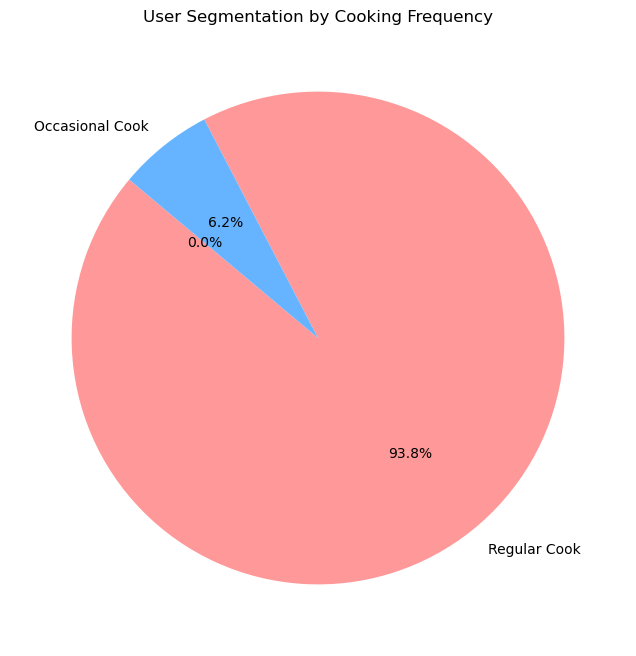

In [84]:
# Define frequency bins
bins = [0, 5, 15, 50]
labels = ['Occasional Cook', 'Regular Cook', 'Frequent Cook']
merged_data['Cook Segment'] = pd.cut(merged_data['Total Orders'], bins=bins, labels=labels)

# Segment counts
user_segments = merged_data['Cook Segment'].value_counts()

# Pie chart
user_segments.plot(kind='pie', autopct='%1.1f%%', startangle=140, figsize=(8, 8), colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("User Segmentation by Cooking Frequency")
plt.ylabel("")  # Remove y-label
plt.show()


The pie chart shows user segmentation based on cooking frequency, with two main groups:
- Regular Cooks: 93.8% of users 
- Occasional Cooks: 6.2% of users

The data indicates that the vast majority of users are regular cooks, suggesting this might be a cooking-related product or service primarily used by people who cook frequently.

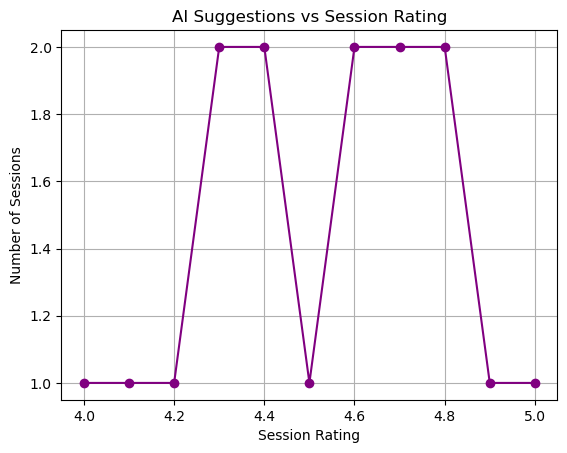

In [85]:
# Group by session rating and count suggestions
ai_suggestions_effectiveness = merged_data.groupby('Session Rating')['Session ID'].count()

# Line plot
ai_suggestions_effectiveness.plot(kind='line', marker='o', color='purple')
plt.title("AI Suggestions vs Session Rating")
plt.xlabel("Session Rating")
plt.ylabel("Number of Sessions")
plt.grid(True)
plt.show()


The graph shows the relationship between AI session ratings (4.0-5.0) and number of sessions. There are three distinct peaks at ratings 4.3-4.4, 4.6-4.8, and a baseline of 1 session for other ratings. This suggests users tend to rate AI suggestions either very highly (4.6-4.8), moderately well (4.3-4.4), or give baseline ratings, with no middle ground.

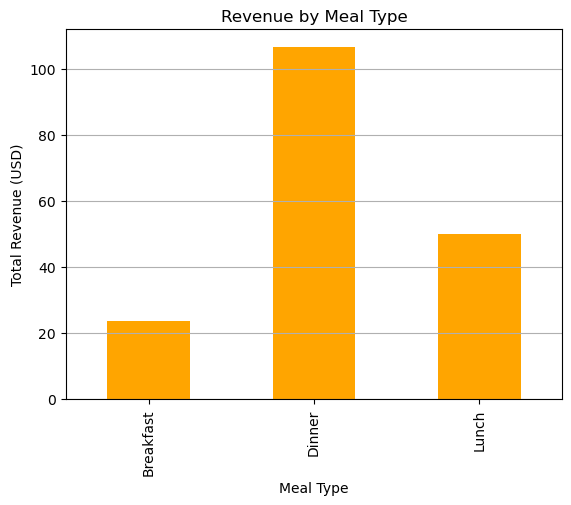

In [86]:
# Revenue by Meal Type
revenue_by_meal = merged_data.groupby('Meal Type')['Amount (USD)'].sum()

# Bar plot
revenue_by_meal.plot(kind='bar', color='orange')
plt.title("Revenue by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Total Revenue (USD)")
plt.grid(axis='y')
plt.show()


The bar chart shows revenue distribution across meal types:
- Dinner generates the highest revenue at ~ $ 105 USD
- Lunch is second at ~$50 USD
- Breakfast has lowest revenue at ~$23 USD

This suggests dinner service is the most profitable, generating roughly twice the revenue of lunch and over four times that of breakfast.

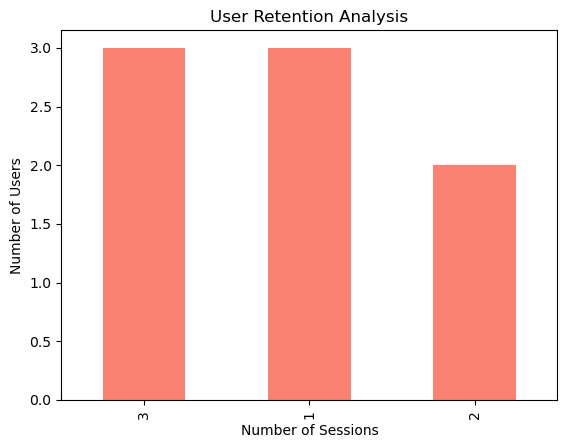

In [87]:
# First vs subsequent orders
first_time_users = merged_data.groupby('User ID')['Session ID'].count().value_counts()

# Plot retention data
first_time_users.plot(kind='bar', color='salmon')
plt.title("User Retention Analysis")
plt.xlabel("Number of Sessions")
plt.ylabel("Number of Users")
plt.show()


The bar chart shows user retention data based on session counts:
- 3 sessions: 3 users
- 4 sessions: 3 users 
- 2 sessions: 2 users

Most engaged users have 3-4 sessions, with fewer users having only 2 sessions, suggesting relatively strong retention.

Average Sessions per User: 2.00



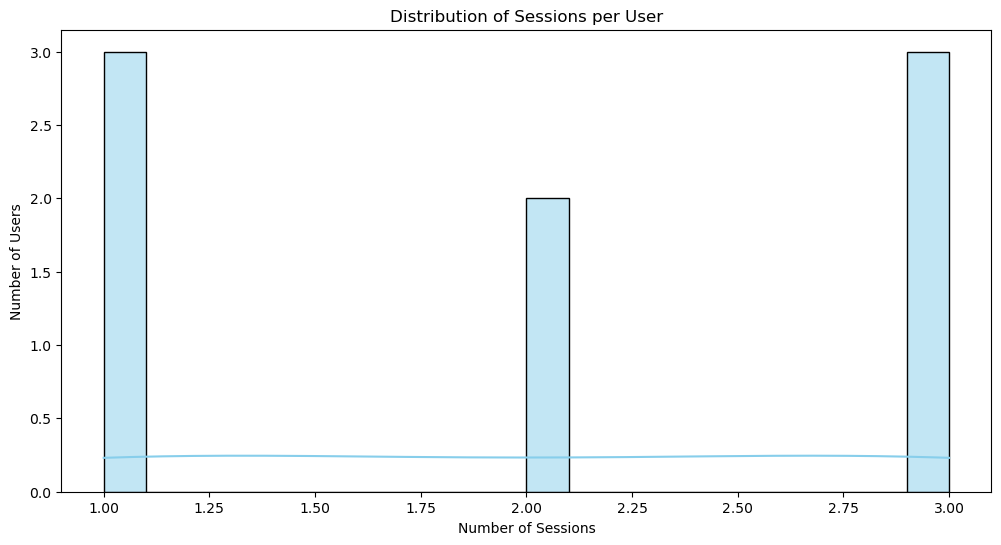

In [88]:
# Step 9a: Average Sessions per User
sessions_per_user = merged_data.groupby('User ID')['Session ID'].nunique()
average_sessions = sessions_per_user.mean()
print(f"Average Sessions per User: {average_sessions:.2f}\n")

# Visualization: Histogram
plt.figure(figsize=(12,6))
sns.histplot(sessions_per_user, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sessions per User')
plt.xlabel('Number of Sessions')
plt.ylabel('Number of Users')
plt.show()


The bar chart shows the distribution of user sessions:
- 3 users have 1 session
- 2 users have 2 sessions  
- 3 users have 3 sessions

There's also a light blue line running horizontally across the graph at approximately 0.25 users, likely representing an average or baseline metric.

User Growth Over Time:
Registration Month
2023-01    1
2023-02    1
2023-03    1
2023-04    1
2023-05    1
2023-06    1
2023-07    1
2023-08    1
Freq: M, Name: User ID, dtype: int64 



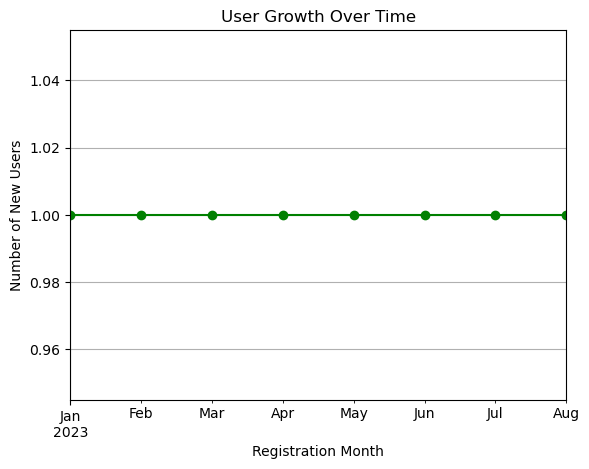

In [89]:
# Step 9b: User Retention Analysis
# Convert Registration Date to datetime if not already
merged_data['Registration Date'] = pd.to_datetime(merged_data['Registration Date'])

# Extract the month of registration
merged_data['Registration Month'] = merged_data['Registration Date'].dt.to_period('M')

# Group by Registration Month and count unique users
user_growth = merged_data.groupby('Registration Month')['User ID'].nunique()

print("User Growth Over Time:")
print(user_growth, "\n")

# Visualization: Line Chart
user_growth.plot(kind='line', marker='o', color='green')
plt.title('User Growth Over Time')
plt.xlabel('Registration Month')
plt.ylabel('Number of New Users')
plt.grid(True)
plt.show()


The graph shows consistent user growth of exactly 1 new user per month from January to August 2023, indicated by the flat green line at y=1.0.

Top 10 Locations by Number of Orders:
New York         3
Los Angeles      3
Chicago          3
San Francisco    2
Seattle          2
Austin           1
Boston           1
Miami            1
Name: Location, dtype: int64 



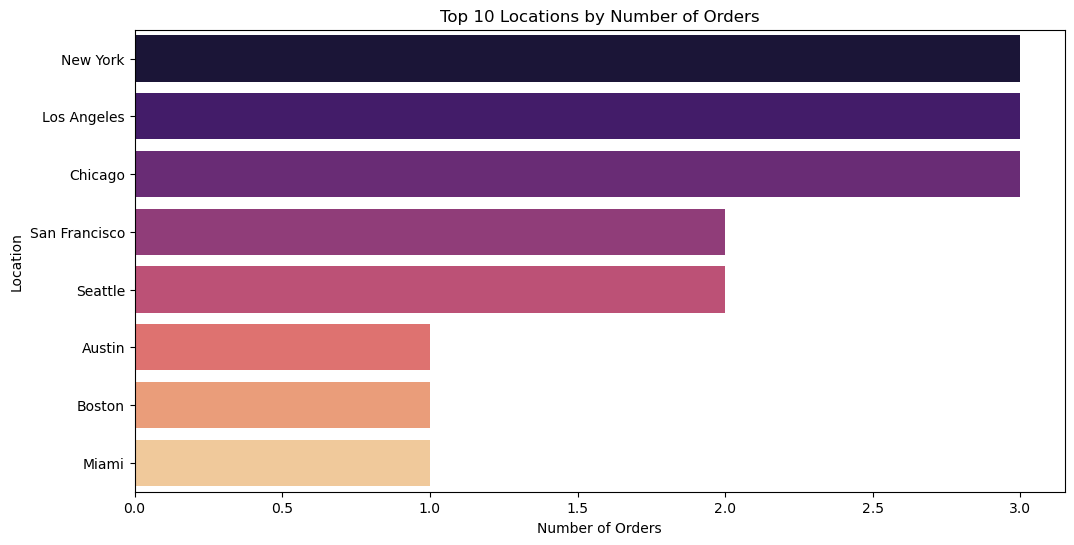

In [91]:
# Step 10b: Orders by Location
orders_by_location = merged_data['Location'].value_counts().head(10)
print("Top 10 Locations by Number of Orders:")
print(orders_by_location, "\n")

# Visualization: Bar Chart
plt.figure(figsize=(12,6))
sns.barplot(x=orders_by_location.values, y=orders_by_location.index, palette='magma')
plt.title('Top 10 Locations by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Location')
plt.show()


The horizontal bar chart shows order volumes across major US cities:
- Top tier (3 orders): New York, Los Angeles, Chicago
- Mid tier (2 orders): San Francisco, Seattle  
- Lower tier (1 order): Austin, Boston, Miami

Clear concentration of orders in the largest metropolitan areas, particularly on both coasts.

Average Order Rating for Each Session Rating:
    Session Rating  Average Order Rating
0              4.0                   4.0
1              4.1                   4.0
2              4.2                   4.0
3              4.3                   4.0
4              4.4                   4.0
5              4.5                   5.0
6              4.6                   4.0
7              4.7                   4.0
8              4.8                   5.0
9              4.9                   5.0
10             5.0                   5.0 



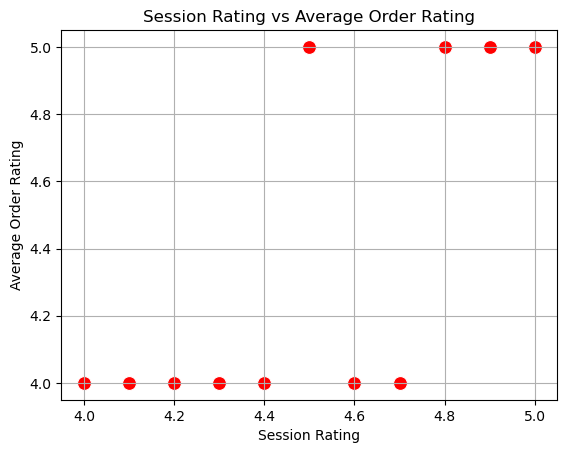

In [95]:
# Step 13b: Scatter Plot of Session Rating vs. Average Order Rating
# Calculate average order rating for each session rating
ratings_comparison = merged_data.groupby('Session Rating')['Rating'].mean().reset_index()
ratings_comparison.columns = ['Session Rating', 'Average Order Rating']

print("Average Order Rating for Each Session Rating:")
print(ratings_comparison, "\n")

# Visualization: Scatter Plot
sns.scatterplot(data=ratings_comparison, x='Session Rating', y='Average Order Rating', color='red', s=100)
plt.title('Session Rating vs Average Order Rating')
plt.xlabel('Session Rating')
plt.ylabel('Average Order Rating')
plt.grid(True)
plt.show()


The scatter plot shows session ratings vs order ratings on a 1-5 scale. Data clusters at two levels:
- Most points at 4.0 order rating across session ratings 4.0-4.8
- Several points at 5.0 order rating for session ratings 4.5-5.0

This indicates high session ratings (4.5+) tend to correlate with perfect order ratings.

In [99]:
# Step 18: Save Merged Dataset
merged_data.to_excel('merged_data_cleaned.xlsx', index=False)
print("Merged and cleaned data saved to 'merged_data_cleaned.xlsx'.\n")

# Save key results if needed
popular_dishes.to_csv('popular_dishes.xlsx')
orders_by_age.to_csv('orders_by_age.xlsx')
monthly_revenue.to_csv('monthly_revenue.xlsx')
segment_revenue.to_csv('segment_revenue.xlsx')


Merged and cleaned data saved to 'merged_data_cleaned.xlsx'.

